In [29]:

from collections import Counter, deque, defaultdict
import networkx as nx
import matplotlib.pyplot as plt

S = "S"
O = "O"
DIVIDE = "/"
DASH = "-"
EQ = "="
M = "M"
W = "W"
Z = "Z"
T = "T"  # Define terminal node

MAX_DEPTH = 8
MAX_CONTIG_N = 3  # No more than 3 contiguous N's (N is W/Z/M)
N_VALS = (W, Z, M)

def is_N(symbol):
    return symbol in N_VALS

def count_trailing_N(path):
    cnt = 0
    for tok in reversed(path):
        if is_N(tok):
            cnt += 1
        else:
            break
    return cnt

def count_max_contiguous_N(path):
    max_n = 0
    curr = 0
    for tok in path:
        if is_N(tok):
            curr += 1
            max_n = max(max_n, curr)
        else:
            curr = 0
    return max_n

def contains_illegal_wwz(path):
    """
    Returns True if any W->W with a Z child branch is not followed immediately
    by [W, O, /, -, =]. This prevents illegal WWZ branching as per the rules.
    """
    for i in range(len(path)-2):
        if path[i] == W and path[i+1] == W and path[i+2] == Z:
            # If W->W->Z, this is not legal: W's after W must either be W, O, /, -, =
            return True
    return False

def has_illegal_z_dash_eq(path):
    """
    Returns True if there is a Z->DASH->EQ sequence.
    """
    for i in range(len(path)-2):
        if path[i] == Z and path[i+1] == DASH and path[i+2] == EQ:
            return True
    return False

def can_terminate_inverted(path):
    """
    See the new rules:
      - Cannot terminate immediately after 'S' ([S, T]) - S must be followed by a number (N=W/Z/M).
      - Cannot terminate on W->Z (must go W->Z->W, so W->Z->T is not allowed).
      - Cannot terminate on ...Z->-, so [-2]==Z and [-1]==DASH.
      - Absolutely NO >3 contiguous N's anywhere in the path.
      - W->W can only be followed by W or O,/,-,=.
      - Only allow termination if last symbol is not O, =, or /.
      - Cannot terminate (or generally allow) Z->DASH->EQ: after Z->DASH, must have N next, not EQ.
      - (Legacy rules preserved where relevant)
    """
    if not path or len(path) < 2:
        return False
    last = path[-1]

    # S cannot terminate directly ([S, T]) or [S, ... T] if not at least one N after S
    if path == [S]:
        return False
    if path[0] == S:
        if len(path) == 2 and path[1] == T:
            return False
        # S must be followed by a N
        if len(path) >= 2 and not is_N(path[1]) and path[1] != T:
            return False
        # Do not allow [S, T]
        if len(path) == 2 and path[1] == T:
            return False

    # No >3 contiguous N's anywhere
    if count_max_contiguous_N(path) > MAX_CONTIG_N:
        return False

    # Cannot terminate if last symbol is O, =, or /
    if last in (O, EQ, DIVIDE):
        return False

    # W->Z cannot terminate: must go W->Z->W...
    if len(path) >= 2 and path[-2] == W and path[-1] == Z:
        return False

    # --- NEW RULE: cannot terminate ... -> Z -> - (i.e., last two are [Z, DASH])
    if len(path) >= 2 and path[-2] == Z and path[-1] == DASH:
        return False

    # Block if any Z->DASH->EQ sequence in the path
    if has_illegal_z_dash_eq(path):
        return False

    # If W->W->Z pattern anywhere, forbid
    if contains_illegal_wwz(path):
        return False

    # W->W can only be followed by W or O, /, -, =
    # (Enforced in tree expansion, but double-check here)
    for i in range(len(path)-2):
        if path[i] == W and path[i+1] == W and path[i+2] not in (W, O, DIVIDE, DASH, EQ):
            return False

    # ---- (Keep other legacy rules) ----

    # 1. S->M=W and =->M=W (no S M W or = M W at end)
    if len(path) >= 3 and (
        (path[-3] == S and path[-2] == M and path[-1] == W) or
        (path[-3] == EQ and path[-2] == M and path[-1] == W)
    ):
        return False
    # 2. S->W=M and S->M=W
    if len(path) >= 3 and (
        (path[-3] == S and path[-2] == W and path[-1] == M) or
        (path[-3] == S and path[-2] == M and path[-1] == W)
    ):
        return False
    # 3. S->W_x = W_y x != y and = -> W_x = W_y
    if EQ in path:
        eq_idx = path.index(EQ)
        # Go left from = for W streak
        left_w = 0
        i = eq_idx - 1
        while i >= 0 and path[i] == W:
            left_w += 1
            i -= 1
        # Go right from = for W streak
        right_w = 0
        i = eq_idx + 1
        while i < len(path) and path[i] == W:
            right_w += 1
            i += 1
        if left_w > 0 and right_w > 0 and left_w != right_w:
            if S in path[:eq_idx-left_w+1]:
                return False
        if eq_idx == 0 and left_w > 0 and right_w > 0 and left_w != right_w:
            return False

    # 4. S->W(1 or 3 in a row)=M and =->W(1 or 3 in a row)=M
    def check_w_streak_before_eq_and_M(path):
        if len(path) >= 4:
            if (path[-4] == S and path[-3] == W and path[-2] == EQ and path[-1] == M) or \
               (path[-4] == EQ and path[-3] == W and path[-2] == EQ and path[-1] == M):
                w_streak = 0
                i = -4
                while abs(i) <= len(path) and path[i] == W:
                    w_streak += 1
                    i -= 1
                if w_streak in (1, 3):
                    return True
        return False

    if check_w_streak_before_eq_and_M(path):
        return False

    def check_M_before_eq_and_W_streak(path):
        if EQ in path:
            eq_idx = path.index(EQ)
            if eq_idx >= 2:
                if path[eq_idx - 2] == S and path[eq_idx - 1] == M:
                    w_streak = 0
                    for tok in path[eq_idx+1:]:
                        if tok == W:
                            w_streak += 1
                        else:
                            break
                    if w_streak in (1,3):
                        return True
                if path[0] == EQ and path[1] == M:
                    w_streak = 0
                    for tok in path[eq_idx+1:]:
                        if tok == W:
                            w_streak += 1
                        else:
                            break
                    if w_streak in (1,3):
                        return True
        return False

    if check_M_before_eq_and_W_streak(path):
        return False

    # 5. S -> N-=N and S -> N=N- (N is stream of M/W/0/Z), or same with = at root
    def is_stream(n):
        return n in (M,W,Z,0,'0')

    if len(path) >= 4:
        # S -> N - = N
        if path[-4] == S and is_stream(path[-3]) and path[-2] == DASH and path[-1] == EQ:
            return False
        # S -> N = N -
        if path[-4] == S and is_stream(path[-3]) and path[-2] == EQ and path[-1] == DASH:
            return False
        # = -> N - = N
        if path[-4] == EQ and is_stream(path[-3]) and path[-2] == DASH and path[-1] == EQ:
            return False
        # = -> N = N -
        if path[-4] == EQ and is_stream(path[-3]) and path[-2] == EQ and path[-1] == DASH:
            return False

    return True

def build_inverted_tree():
    """
    Build a TREE with these rules:
      - No more than MAX_CONTIG_N=3 contiguous Ns (N is W/Z/M) *ANYWHERE* in the path.
      - If the current path would create >3 contiguous Ns *anywhere*, do not branch or terminate here.
      - If you have hit 3 contiguous Ns (trailing), you must branch next to a non-N (O, /, -, =, T).
      - Z -> Z is allowed, BUT after Z->Z you must have W as the next child; and that W must be forced to immediately have as children only O,/, -, = (not N)
      - Z -> W is allowed, but after Z->W, the W **must** be immediately forced to have as children only O, /, -, = (not N)
      - W->W can only be followed by W or O,/,-,=
      - You cannot terminate after S ([S,T]), S must be followed by one N
      - You cannot terminate on W->Z, must go W->Z->W only
      - You cannot terminate on ...Z -> -
      - Z->DASH->EQ is forbidden: after Z->DASH, you can only have an N (not EQ, not O, etc)
    """
    G = nx.DiGraph()
    node_labels = {}

    def get_node_id(path):
        return tuple(path)

    root_path = [S]
    root_nodeid = get_node_id(root_path)
    G.add_node(root_nodeid, label=S)
    node_labels[root_nodeid] = S

    queue = deque()
    queue.append((root_path,))

    while queue:
        (path,) = queue.popleft()
        cur_symbol = path[-1]
        cur_nodeid = get_node_id(path)
        depth = len(path) - 1

        # HARD CUT: If this path has >3 contiguous N's anywhere, do not expand it further
        if count_max_contiguous_N(path) > MAX_CONTIG_N:
            continue

        # HARD CUT: block any path that contains illegal Z->D->EQ pattern anywhere
        if has_illegal_z_dash_eq(path):
            continue

        # Cannot terminate after [S], must be at least [S, N] before considering ending
        if depth >= MAX_DEPTH:
            if can_terminate_inverted(path):
                # Also block if last two are [Z, DASH] (terminate after Z- is forbidden)
                if not (len(path) >= 2 and path[-2] == Z and path[-1] == DASH):
                    t_path = path + [T]
                    t_id = get_node_id(t_path)
                    G.add_node(t_id, label=T)
                    node_labels[t_id] = T
                    G.add_edge(cur_nodeid, t_id)
            continue

        if can_terminate_inverted(path):
            # Also block if last two are [Z, DASH] (terminate after Z- is forbidden)
            if not (len(path) >= 2 and path[-2] == Z and path[-1] == DASH):
                t_path = path + [T]
                t_id = get_node_id(t_path)
                G.add_node(t_id, label=T)
                node_labels[t_id] = T
                G.add_edge(cur_nodeid, t_id)

        trailing_N = count_trailing_N(path)
        if trailing_N >= MAX_CONTIG_N:
            # After 3 contiguous N's at the tail, only allow non-N's (O, /, -, =)
            possible_children = [O, DIVIDE, DASH, EQ]
        else:
            if cur_symbol == S:
                # S must be followed by only [W, Z, M]
                possible_children = [W, Z, M]
            elif cur_symbol == O:
                possible_children = [W, Z, M]
            elif cur_symbol == DIVIDE:
                possible_children = [W, Z, M]
            elif cur_symbol == DASH:
                # If the parent is Z, then after Z->DASH, can only have N (W/Z/M), not EQ, nor O, nor '/'
                if len(path) >= 2 and path[-2] == Z:
                    possible_children = [W, Z, M]
                else:
                    possible_children = [W, Z, M, EQ]
            elif cur_symbol == EQ:
                possible_children = [W, Z, M]
            elif cur_symbol == M:
                possible_children = [O, DIVIDE, DASH, EQ]
            elif cur_symbol == W:
                # W->W can only be followed by W or O,/,-,=, so filter accordingly
                prev_symbol = path[-2] if len(path) >= 2 else None
                if prev_symbol == W:
                    possible_children = [W, O, DIVIDE, DASH, EQ]
                else:
                    possible_children = [Z, W, O, DIVIDE, DASH, EQ]
            elif cur_symbol == Z:
                # Z->Z, Z->W, Z->O, Z->-, Z->=
                possible_children = [Z, W, O, DASH, EQ]
            else:
                possible_children = []
        # For root S, always only [W, Z, M]
        if cur_symbol == S:
            possible_children = [W, Z, M]

        for child in possible_children:
            # --- Z->DASH->EQ restriction: If expanding Z->DASH, do not allow EQ after
            # (already handled in possible_children above, so EQ is omitted if cur is DASH and prev is Z)
            # --- Z SPECIAL LOGIC ---
            # Z->W: W must be forced to only O, /, -, =
            if cur_symbol == Z and child == W:
                child_path = path + [child]
                if count_max_contiguous_N(child_path) > MAX_CONTIG_N:
                    continue
                # Also block if creating Z->DASH->EQ with this expansion
                # (but W can't be EQ, so safe)
                child_id = get_node_id(child_path)
                if child_id not in G:
                    G.add_node(child_id, label=child)
                    node_labels[child_id] = child
                    # Force next children for W: O, /, -, =
                    for forced_after in [O, DIVIDE, DASH, EQ]:
                        forced_path = child_path + [forced_after]
                        if count_max_contiguous_N(forced_path) > MAX_CONTIG_N:
                            continue
                        # Forbid W->W->Z pattern at the expansion phase
                        if len(child_path) >= 2 and child_path[-2] == W and forced_after == Z:
                            continue
                        # For Z->DASH->EQ restriction: do not allow Z->DASH->EQ at all
                        if len(forced_path) >= 3 and forced_path[-3] == Z and forced_path[-2] == DASH and forced_path[-1] == EQ:
                            continue
                        forced_id = get_node_id(forced_path)
                        if forced_id not in G:
                            G.add_node(forced_id, label=forced_after)
                            node_labels[forced_id] = forced_after
                            queue.append((forced_path,))
                        G.add_edge(child_id, forced_id)
                G.add_edge(cur_nodeid, child_id)
                continue

            # Z->Z: after this, must immediately add W, and then W only gets O,/, -, =
            if cur_symbol == Z and child == Z:
                child_path = path + [child]   # path + [Z]
                if count_max_contiguous_N(child_path) > MAX_CONTIG_N:
                    continue
                child_id = get_node_id(child_path)
                if child_id not in G:
                    G.add_node(child_id, label=child)
                    node_labels[child_id] = child
                    # Only one expansion: immediately W as next
                    zz_w_path = child_path + [W]
                    if count_max_contiguous_N(zz_w_path) > MAX_CONTIG_N:
                        continue
                    zz_w_id = get_node_id(zz_w_path)
                    if zz_w_id not in G:
                        G.add_node(zz_w_id, label=W)
                        node_labels[zz_w_id] = W
                        # Force W's children: O,/, -, =
                        for forced_after in [O, DIVIDE, DASH, EQ]:
                            forced_path = zz_w_path + [forced_after]
                            if count_max_contiguous_N(forced_path) > MAX_CONTIG_N:
                                continue
                            # Forbid W->W->Z at the expansion phase
                            if len(zz_w_path) >= 2 and zz_w_path[-2] == W and forced_after == Z:
                                continue
                            # For Z->DASH->EQ restriction: do not allow Z->DASH->EQ at all
                            if len(forced_path) >= 3 and forced_path[-3] == Z and forced_path[-2] == DASH and forced_path[-1] == EQ:
                                continue
                            forced_id = get_node_id(forced_path)
                            if forced_id not in G:
                                G.add_node(forced_id, label=forced_after)
                                node_labels[forced_id] = forced_after
                                queue.append((forced_path,))
                            G.add_edge(zz_w_id, forced_id)
                    G.add_edge(child_id, zz_w_id)
                G.add_edge(cur_nodeid, child_id)
                continue

            # Expansion: for W->W, do not allow W->W->Z (illegal)
            if cur_symbol == W and child == W:
                prev_symbol = path[-2] if len(path) >= 2 else None
                # Do not allow W->W->Z
                # Since the loop follows with child_path, prevent child_path+[Z] as a direct child
                child_path = path + [child]
                if count_max_contiguous_N(child_path) > MAX_CONTIG_N:
                    continue
                # For Z->DASH->EQ restriction, it's impossible here since W->W can't yield that
                child_id = get_node_id(child_path)
                if child_id not in G:
                    G.add_node(child_id, label=child)
                    node_labels[child_id] = child
                    queue.append((child_path,))
                G.add_edge(cur_nodeid, child_id)
                # When expanding W->W, W's children must only be W or O,/,-,=.
                # This is already enforced in possible_children for prev_symbol == W, so skip special logic here.
                continue

            # Forbid W->W->Z in general by filtering child_path
            if len(path) >= 1 and path[-1] == W and child == Z:
                prev_symbol = path[-2] if len(path) >= 2 else None
                if prev_symbol == W:
                    # W->W->Z is illegal
                    continue

            # W->Z: do not allow immediate termination, must add forced W as next step
            if cur_symbol == W and child == Z:
                # Only allow W->Z->W, not W->Z->T or W->Z->non-W
                zw_path = path + [child]  # path + [Z]
                # Must not create >3 contiguous N
                if count_max_contiguous_N(zw_path) > MAX_CONTIG_N:
                    continue
                zw_id = get_node_id(zw_path)
                if zw_id not in G:
                    G.add_node(zw_id, label=Z)
                    node_labels[zw_id] = Z
                    # Only one forced child, W
                    zw_w_path = zw_path + [W]
                    if count_max_contiguous_N(zw_w_path) > MAX_CONTIG_N:
                        continue
                    zw_w_id = get_node_id(zw_w_path)
                    if zw_w_id not in G:
                        G.add_node(zw_w_id, label=W)
                        node_labels[zw_w_id] = W
                        queue.append((zw_w_path,))
                    G.add_edge(zw_id, zw_w_id)
                G.add_edge(cur_nodeid, zw_id)
                continue

            # All other moves, normal logic
            child_path = path + [child]
            # Forbid W->W->Z at expansion time
            if len(path) >= 1 and path[-1] == W and child == Z:
                prev_symbol = path[-2] if len(path) >= 2 else None
                if prev_symbol == W:
                    continue
            if count_max_contiguous_N(child_path) > MAX_CONTIG_N:
                continue

            # For Z->DASH->EQ restriction: If the last three tokens in the new child path are Z->DASH->EQ,
            # skip that expansion entirely.
            if len(child_path) >= 3 and child_path[-3] == Z and child_path[-2] == DASH and child_path[-1] == EQ:
                continue

            #--- New: prevent creating ... -> Z -> DASH -> T
            # We'll prevent adding a child == T to any node whose previous 2 are [Z, DASH]
            # But this is already handled in can_terminate_inverted and in the T-adding spot above!
            child_id = get_node_id(child_path)
            if child_id not in G:
                G.add_node(child_id, label=child)
                node_labels[child_id] = child
                queue.append((child_path,))
            G.add_edge(cur_nodeid, child_id)

    return G, node_labels

# Build and display the tree

inverted_G, inverted_labels = build_inverted_tree()

# Node counts and T's for debug
type_cnt_inv = Counter()
for nodeid in inverted_G.nodes:
    label = inverted_G.nodes[nodeid].get("label", "")
    type_cnt_inv[label] += 1
num_terminators_inv = type_cnt_inv.get(T, 0)

print("Node counts in inverted TREE:", type_cnt_inv)
print("Number of terminal nodes (T):", num_terminators_inv)
print("Total nodes in inverted TREE:", len(inverted_G.nodes))

# Uncomment for visualization if needed
# try:
#     inv_pos = nx.nx_pydot.graphviz_layout(inverted_G, prog='dot')
# except Exception:
#     inv_pos = nx.spring_layout(inverted_G)

# def show_path_label(node_tuple):
#     symbol = node_tuple[-1]
#     depth = len(node_tuple) - 1
#     return f"{symbol}\ndepth={depth}"

# draw_labels_inv = {k: show_path_label(k) for k in inverted_G.nodes}

# plt.figure(figsize=(20, 14))
# nx.draw(inverted_G, inv_pos, with_labels=True, labels=draw_labels_inv, arrows=False, node_size=200, node_color='lightyellow', font_size=10)
# plt.title("Inverted S → N TREE (N=W,Z,M), max 3 contiguous N, otherwise legacy expansion")
# plt.tight_layout(pad=3.0)
# plt.show()

# plt.show()



Node counts in inverted TREE: Counter({'T': 30268, 'W': 14951, '=': 12429, 'O': 11289, '-': 11289, 'Z': 10333, '/': 9170, 'M': 6095, 'S': 1})
Number of terminal nodes (T): 30268
Total nodes in inverted TREE: 105825


In [30]:
def get_terminal_paths_tree(tree, T, start_node=None):
    """
    Find all paths from the root to terminal nodes labeled T in a tree,
    returning paths as lists of labels.
    If start_node is not given, starts from the root (the unique node with in-degree 0).
    Assumes 'tree' is a directed tree (no cycles, unique parent for all nodes except root).
    """
    import networkx as nx

    if start_node is None:
        # In a tree, the root has in-degree 0
        roots = [n for n in tree.nodes if tree.in_degree(n) == 0]
        if not roots:
            raise ValueError("No root found in the tree.")
        start_node = roots[0]

    results = []

    def dfs(node, path):
        node_label = tree.nodes[node].get("label", "")
        new_path = path + [node_label]
        children = list(tree.successors(node))
        if not children:
            if node_label == T:
                results.append(new_path)
        else:
            for child in children:
                dfs(child, new_path)

    dfs(start_node, [])

    return results

terminal_paths_tree = get_terminal_paths_tree(inverted_G, T)
for p in terminal_paths_tree:
    print(p)
print(len(terminal_paths_tree))


['S', 'W', 'T']
['S', 'W', 'Z', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'Z', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'Z', 'W', '-', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'W', '-', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'O', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'O', 'Z', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', 'O', 'M', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '/', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '/', 'Z', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '/', 'M', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '-', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '-', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '-', 'Z', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '-', 'M', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '=', 'Z', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'W', '=', 'M', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'O', 'W', 'T']
['S', 'W', 'Z', 'W', 'O', 'W', 'O'

In [31]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, deque

S = "S"
O = "O"
DIVIDE = "/"
DASH = "-"
EQ = "="
M = "M"
W = "W"
Z = "Z"
T = "T"

MAX_DEPTH = 8
MAX_CONTIG_W = 3

# --- your can_terminate stays EXACTLY the same ---
def can_terminate(path):
    if len(path) == 1 and path[0] == S:
        return False

    if len(path) >= 4 and (path[-4:] == [S, M, EQ, W] or path[-4:] == [EQ, M, EQ, W]):
        return False

    if len(path) >= 4 and (path[-4:] == [S, W, EQ, M] or path[-4:] == [EQ, W, EQ, M]):
        return False

    if EQ in path:
        eq_idx = path.index(EQ)
        left_w = 0
        i = eq_idx - 1
        while i >= 0 and path[i] == W:
            left_w += 1
            i -= 1
        right_w = 0
        i = eq_idx + 1
        while i < len(path) and path[i] == W:
            right_w += 1
            i += 1
        if left_w > 0 and right_w > 0 and left_w != right_w:
            if S in path[:eq_idx - left_w + 1]:
                return False
        if len(path) >= eq_idx + 2:
            if path[0] == EQ and left_w > 0 and right_w > 0 and left_w != right_w:
                return False

    if EQ in path:
        eq_idx = path.index(EQ)
        left_w = 0
        i = eq_idx - 1
        while i >= 0 and path[i] == W:
            left_w += 1
            i -= 1
        if left_w in (1, 3) and eq_idx + 1 < len(path) and path[eq_idx + 1] == M:
            if S in path[:eq_idx - left_w + 1]:
                return False
            if path[0] == EQ:
                return False

    if len(path) >= 4 and ((path[-4] == S and path[-3] == M and path[-2] == EQ) or
                           (path[-4] == EQ and path[-3] == M and path[-2] == EQ)):
        i = len(path) - 1
        w_streak = 0
        while i > -1 and path[i] == W:
            w_streak += 1
            i -= 1
        if w_streak in (1, 3):
            return False

        eq_idx = len(path) - 2
        w_after_eq = 0
        for tok in path[eq_idx + 1:]:
            if tok == W:
                w_after_eq += 1
            else:
                break
        if w_after_eq in (1, 3):
            return False

    if len(path) >= 5:
        if path[-5] == S and path[-4] == DASH and path[-2] == EQ:
            n1_seq = []
            i = -3
            while abs(i) < len(path) and path[i] in (M, W, Z, '0', 0):
                n1_seq.append(path[i])
                i -= 1
            if len(n1_seq) >= 1:
                n2_seq = []
                i = -1
                while abs(i) <= len(path) and path[i] in (M, W, Z, '0', 0):
                    n2_seq.append(path[i])
                    i -= 1
                if len(n2_seq) >= 1:
                    return False

        if path[-5] == EQ and path[-4] == DASH and path[-2] == EQ:
            n1_seq = []
            i = -3
            while abs(i) < len(path) and path[i] in (M, W, Z, '0', 0):
                n1_seq.append(path[i])
                i -= 1
            if len(n1_seq) >= 1:
                n2_seq = []
                i = -1
                while abs(i) <= len(path) and path[i] in (M, W, Z, '0', 0):
                    n2_seq.append(path[i])
                    i -= 1
                if len(n2_seq) >= 1:
                    return False

        if path[-5] == S and path[-3] == EQ and path[-2] == DASH:
            n1_seq = []
            i = -4
            while abs(i) < len(path) and path[i] in (M, W, Z, '0', 0):
                n1_seq.append(path[i])
                i -= 1
            if len(n1_seq) >= 1:
                n2_seq = []
                i = -1
                while abs(i) <= len(path) and path[i] in (M, W, Z, '0', 0):
                    n2_seq.append(path[i])
                    i -= 1
                if len(n2_seq) >= 1:
                    return False

        if path[-5] == EQ and path[-3] == EQ and path[-2] == DASH:
            n1_seq = []
            i = -4
            while abs(i) < len(path) and path[i] in (M, W, Z, '0', 0):
                n1_seq.append(path[i])
                i -= 1
            if len(n1_seq) >= 1:
                n2_seq = []
                i = -1
                while abs(i) <= len(path) and path[i] in (M, W, Z, '0', 0):
                    n2_seq.append(path[i])
                    i -= 1
                if len(n2_seq) >= 1:
                    return False

    if path[-1] in (O, EQ, DASH, DIVIDE):
        return False

    return True


def build_custom_tree():
    """
    TREE version of your DAG:
      - Node id is the FULL PATH (tuple), so same symbol at same depth is NOT shared.
      - All expansion rules + W-streak constraint remain the same.
    """
    G = nx.DiGraph()
    node_labels = {}

    def node_id(path):
        return tuple(path)  # <-- key change: path identity

    root_path = [S]
    root_id = node_id(root_path)
    G.add_node(root_id, label=S)
    node_labels[root_id] = S

    queue = deque()
    # queue items: (path, w_streak)
    queue.append((root_path, 0))

    while queue:
        path, w_streak = queue.popleft()
        depth = len(path) - 1
        nodetype = path[-1]
        cur_id = node_id(path)

        # Depth cutoff
        if depth >= MAX_DEPTH:
            if can_terminate(path):
                t_path = path + [T]
                t_id = node_id(t_path)
                if t_id not in G:
                    G.add_node(t_id, label=T)
                    node_labels[t_id] = T
                G.add_edge(cur_id, t_id)
            continue

        # Terminate edge if allowed
        if can_terminate(path):
            t_path = path + [T]
            t_id = node_id(t_path)
            if t_id not in G:
                G.add_node(t_id, label=T)
                node_labels[t_id] = T
            G.add_edge(cur_id, t_id)

        def add_child(child_symbol):
            # update W streak
            if child_symbol == W:
                new_ws = w_streak + 1
            else:
                new_ws = 0

            # W streak constraint
            if child_symbol == W and new_ws > MAX_CONTIG_W:
                return

            child_path = path + [child_symbol]
            child_id = node_id(child_path)

            if child_id not in G:
                G.add_node(child_id, label=child_symbol)
                node_labels[child_id] = child_symbol
                queue.append((child_path, new_ws))

            G.add_edge(cur_id, child_id)

        # Expansion rules (same as your DAG)
        if nodetype == S:
            add_child(DASH)
            add_child(M)
            add_child(W)
            add_child(Z)
        elif nodetype == DASH:
            add_child(M)
            add_child(W)
        elif nodetype == EQ:
            add_child(M)
            add_child(W)
            add_child(Z)
            add_child(DASH)
        elif nodetype == M:
            add_child(O)
            add_child(EQ)
            add_child(DIVIDE)
            add_child(DASH)
        elif nodetype == Z:
            # Z->Z only if previous was W (W->Z->Z)
            if len(path) >= 2 and path[-2] == W:
                add_child(Z)
            add_child(O)
            add_child(EQ)
            add_child(DIVIDE)
            add_child(DASH)
        elif nodetype == W:
            add_child(W)
            add_child(Z)
            add_child(O)
            add_child(EQ)
            add_child(DIVIDE)
            add_child(DASH)
        elif nodetype == O:
            add_child(M)
            add_child(W)
            add_child(Z)
        elif nodetype == DIVIDE:
            add_child(M)
            add_child(W)

    return G, node_labels


custom_G, custom_labels = build_custom_tree()

type_cnt = Counter()
for nodeid in custom_G.nodes:
    type_cnt[custom_G.nodes[nodeid].get("label", "")] += 1

print("Node counts in custom TREE:", type_cnt)
print("Number of T nodes:", type_cnt.get(T, 0))
print("Total nodes:", len(custom_G.nodes))
print("Total edges:", len(custom_G.edges))

# try:
#     pos = nx.nx_pydot.graphviz_layout(custom_G, prog="dot")
# except Exception:
#     pos = nx.spring_layout(custom_G)

# draw_labels = {k: f"{custom_labels[k]}\n{list(k)}" for k in custom_G.nodes}

# plt.figure(figsize=(20, 14))
# nx.draw(custom_G, pos, with_labels=True, labels=draw_labels, arrows=False,
#         node_size=200, node_color="lightcyan", font_size=8)
# plt.title("Custom TREE (no merging): node id = full path")
# plt.tight_layout(pad=3.0)
# plt.show()


Node counts in custom TREE: Counter({'T': 22320, 'W': 10361, '-': 9137, 'M': 7522, 'O': 7394, '=': 7394, '/': 7394, 'Z': 7223, 'S': 1})
Number of T nodes: 22320
Total nodes: 78746
Total edges: 78745


In [32]:
terminal_paths_tree = get_terminal_paths_tree(custom_G, T)
for p in terminal_paths_tree:
    print(p)
print(len(terminal_paths_tree))


['S', '-', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', 'O', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', 'O', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', 'O', 'Z', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '=', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '=', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '=', 'Z', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '/', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '/', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '-', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'M', '-', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'W', 'W', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'W', 'Z', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'Z', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'Z', 'Z', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'O', 'M', 'T']
['S', '-', 'M', 'O', 'M', 'O', 'W', 'O', 'W', 'T']
['S', '-'

Node counts in pruned TREE: Counter({'T': 3, 'W': 2, 'S': 1, 'M': 1})
Number of T nodes: 3
Total nodes: 7
Total edges: 6


/var/folders/h1/_n_bj8qj1nd9nhqqdqkdgdt40000gn/T/ipykernel_57808/2449465976.py:88: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which hasknown issues and is not actively maintained. Consider usingnx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos = nx.nx_pydot.graphviz_layout(pruned_tree_G, prog='dot')
/var/folders/h1/_n_bj8qj1nd9nhqqdqkdgdt40000gn/T/ipykernel_57808/2449465976.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


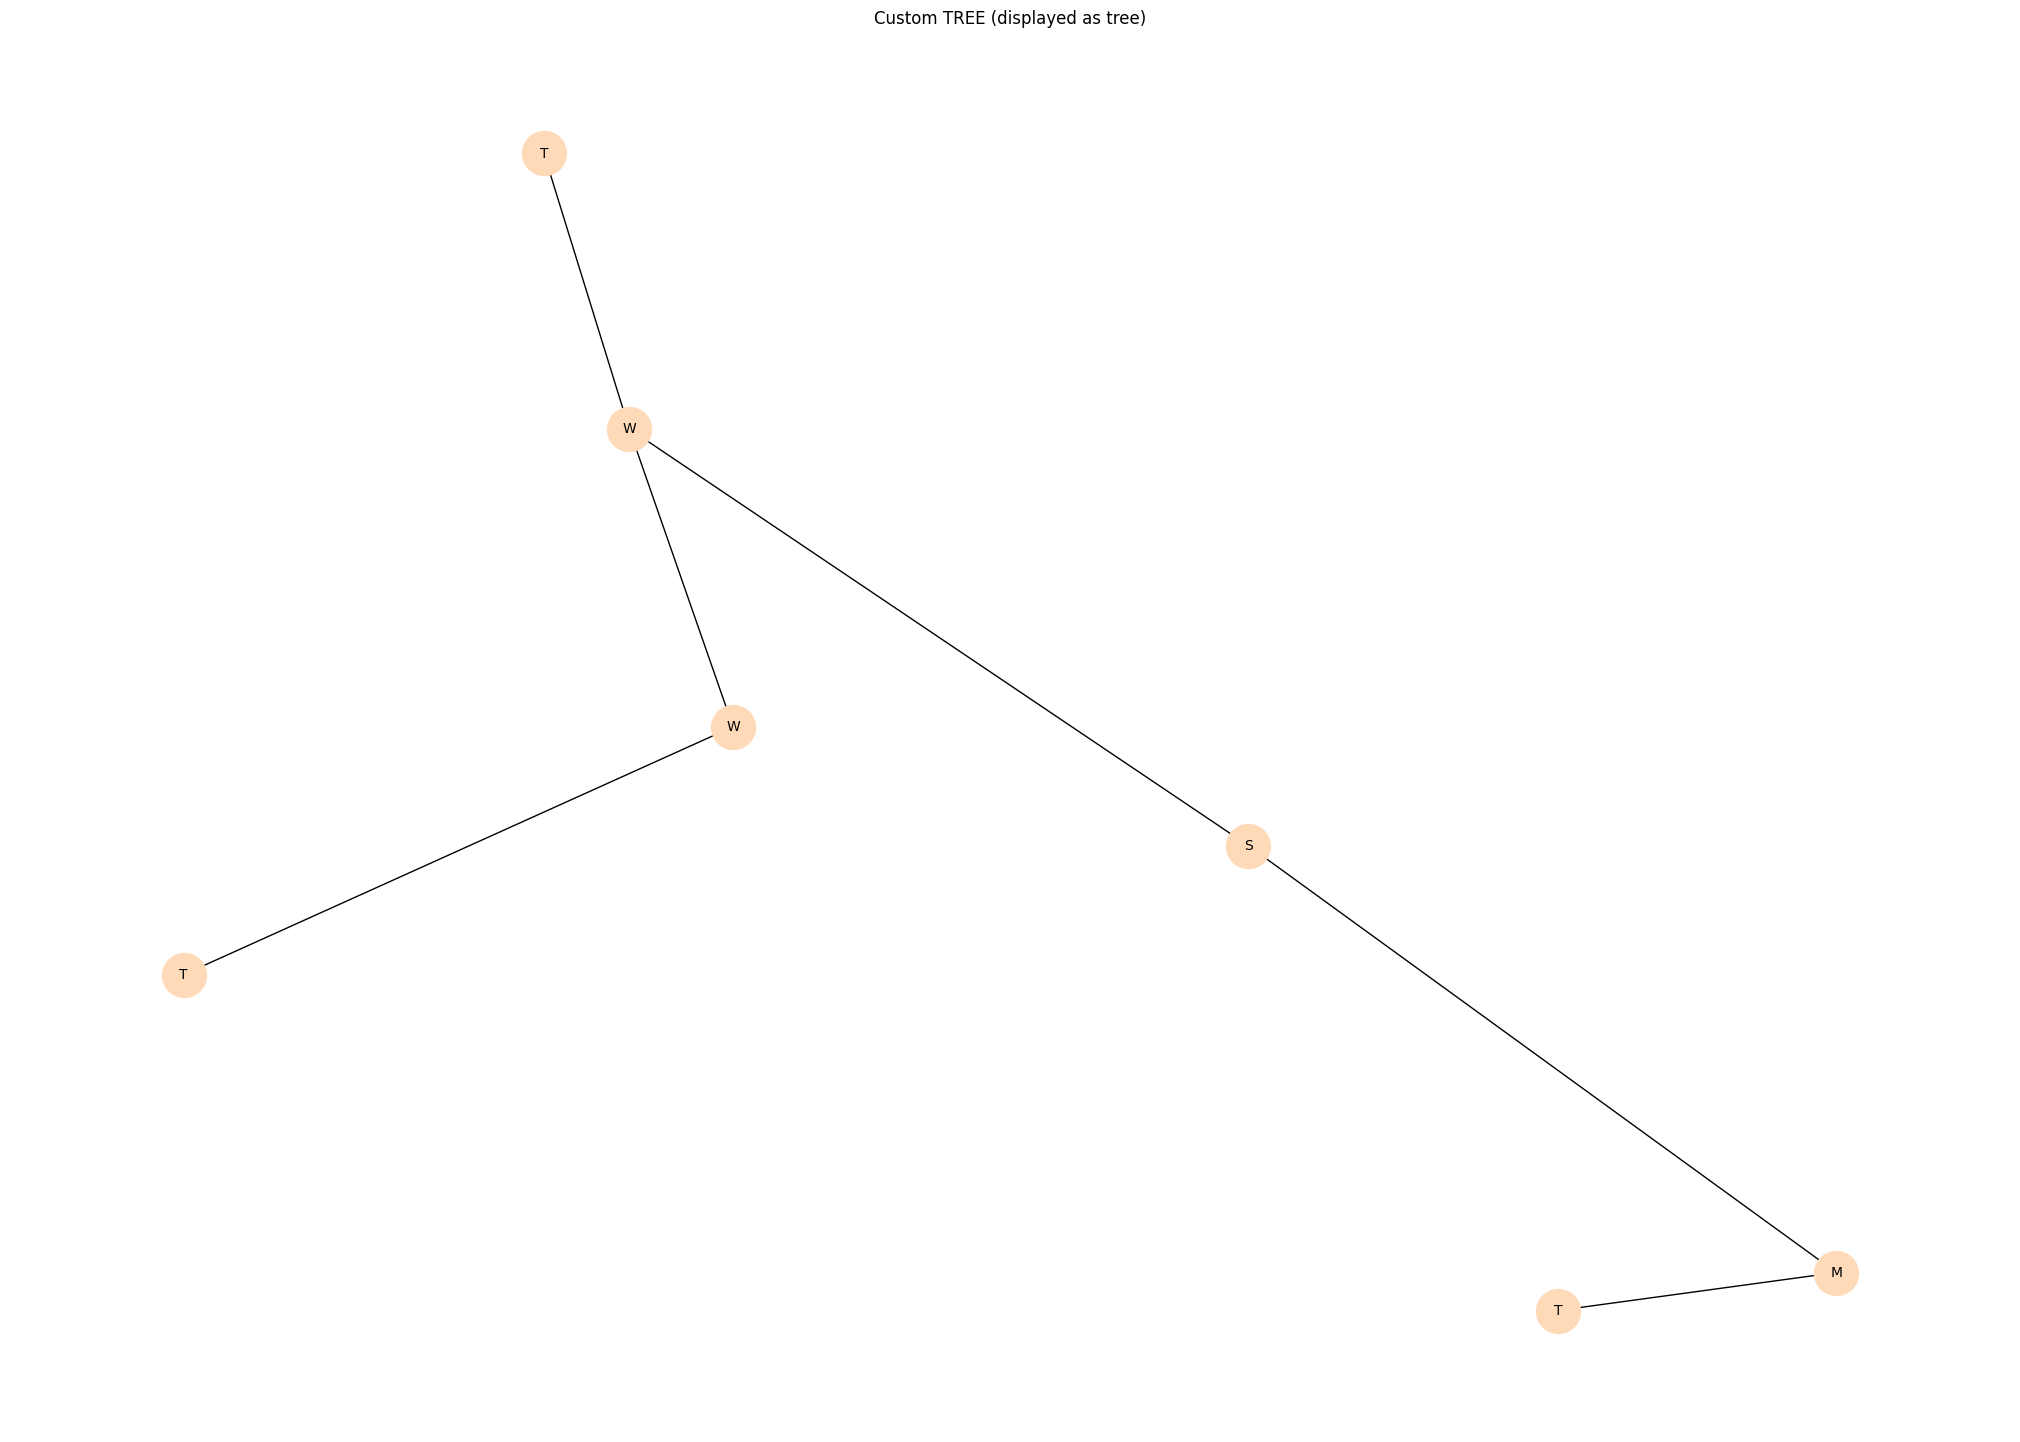

In [33]:
import networkx as nx
from collections import Counter

def prune_tree(G, target_counts, T, S):
    """
    Return a new pruned TREE (as a new nx.DiGraph) from a TREE G,
    such that no root->node path contains more than allowed counts (target_counts)
    for any counted label.

    Assumes G is a tree rooted at label S (i.e., unique paths), such as your custom tree
    where node ids are full path tuples.

    Behavior matches your DAG version:
      - If a node would exceed counts, that entire branch is cut.
      - Non-T leaves are dropped (i.e., only keep leaves that are T).
    """
    pruned_G = nx.DiGraph()

    # Count only labels that appear in target_counts (except S and T)
    count_keys = set(target_counts.keys()) - {S, T}

    # find root
    root = None
    for nodeid in G.nodes:
        if G.nodes[nodeid].get("label", "") == S:
            root = nodeid
            break
    if root is None:
        raise ValueError("No S root node found in tree")

    def dfs(old_node, parent_new, curr_counts):
        label = G.nodes[old_node].get("label", "")

        # update counts if relevant
        next_counts = curr_counts.copy()
        if label in count_keys:
            limit = target_counts.get(label, 0)
            if limit <= 0:
                return  # not allowed at all
            if curr_counts[label] >= limit:
                return  # would exceed
            next_counts[label] += 1

        # add this node to pruned tree (tree => 1:1 mapping old->new is fine)
        if old_node not in pruned_G:
            pruned_G.add_node(old_node, label=label)
        if parent_new is not None:
            pruned_G.add_edge(parent_new, old_node)

        children = list(G.successors(old_node))
        if not children:
            # leaf: keep only if it's T, otherwise remove it
            if label != T:
                pruned_G.remove_node(old_node)
            return

        # recurse
        for ch in children:
            dfs(ch, old_node, next_counts)

        # cleanup: if after pruning this node became a non-T leaf, drop it too
        if pruned_G.has_node(old_node):
            if pruned_G.out_degree(old_node) == 0 and label != T:
                pruned_G.remove_node(old_node)

    dfs(root, None, Counter())
    return pruned_G


def label_counts_on_graph(G):
    return Counter(G.nodes[n].get("label", "") for n in G.nodes)


# Example target counts (same as yours; tweak as needed)
target_counts = {O: 0, M: 2, W: 2, Z: 0, DASH: 0, EQ: 0, DIVIDE: 0}

# Prune your CUSTOM TREE (not the DAG)
pruned_tree_G = prune_tree(custom_G, target_counts, T, S)

custom_counts = label_counts_on_graph(pruned_tree_G)
print("Node counts in pruned TREE:", custom_counts)
print("Number of T nodes:", custom_counts.get(T, 0))
print("Total nodes:", len(pruned_tree_G.nodes))
print("Total edges:", len(pruned_tree_G.edges))


try:
    pos = nx.nx_pydot.graphviz_layout(pruned_tree_G, prog='dot')
except Exception:
    pos = nx.spring_layout(pruned_tree_G)

draw_labels = nx.get_node_attributes(pruned_tree_G, "label")
plt.figure(figsize=(20, 14))
nx.draw(pruned_tree_G, pos, with_labels=True, labels=draw_labels, arrows=False,
        node_size=1000, node_color='peachpuff', font_size=10)
plt.title("Custom TREE (displayed as tree)")
plt.tight_layout(pad=3.0)
plt.show()




In [34]:
# Given an input mapping (dict) of {type: value}, where sum of values == N,
# for each way to split into (left_sum, right_sum) with left_sum + right_sum = N,
# enumerate all unordered splits of the MULTISET (all items, as individuals) into left_sum/right_sum,
# Each split is described by counts per type in each part; splits that differ by which particular 'M' or 'O'
# are NOT counted as different, so only bag counts matter (unordered multiset partition)
# Example: left: {O:1, M:1}, right: {O:1, M:1, W:3, EQ:1} is different from left: {O:2}, right: {M:2, W:3, EQ:1}, etc.
# 
# Edit: Each side (lhs, rhs) MUST contain at least one of M or W or Z.

from collections import Counter
from itertools import product

input_mapping = {'O': 1, 'M': 1, 'W': 2, 'Z': 1, 'DASH': 1, 'EQ': 1, 'DIVIDE': 1}
types = list(input_mapping.keys())
N = sum(input_mapping.values())

def all_type_count_selections(types, input_counts, target_total):
    """
    For the given type list and their total counts, yield all dicts {type: count} summing to target_total,
    with each type's count from 0 up to its input_count.
    """
    ranges = [range(input_counts[t] + 1) for t in types]
    for counts in product(*ranges):
        if sum(counts) == target_total:
            yield dict(zip(types, counts))

def subtract_counts(full, sub):
    # Returns a dict of full - sub for each type
    return {k: full[k] - sub.get(k,0) for k in full}

# Helper: represent each partition signature for unorderedness (sort types in a fixed order)
def partition_signature(left_counts, right_counts, types):
    left_tuple = tuple((t, left_counts.get(t, 0)) for t in types)
    right_tuple = tuple((t, right_counts.get(t, 0)) for t in types)
    return frozenset([left_tuple, right_tuple])

def is_valid_side(cnt):
    # Require at least one of M, W, or Z
    return (cnt.get("M", 0) > 0) or (cnt.get("W", 0) > 0) or (cnt.get("Z", 0) > 0)

big_sum = 0
for left_sum in range(1, N//2 + 1):
    right_sum = N - left_sum
    seen_partitions = set()
    count = 0
    for left_counts in all_type_count_selections(types, input_mapping, left_sum):
        right_counts = subtract_counts(input_mapping, left_counts)
        # Apply validity conditions: both sides must have at least one M/W/Z
        if not (is_valid_side(left_counts) and is_valid_side(right_counts)):
            continue
        sig = partition_signature(left_counts, right_counts, types)
        if sig in seen_partitions:
            continue
        seen_partitions.add(sig)
        # Only print if both sides have at least one element!
        left_counts_str = ', '.join(f"{k}:{v}" for k, v in left_counts.items() if v > 0)
        right_counts_str = ', '.join(f"{k}:{v}" for k, v in right_counts.items() if v > 0)
        print(f"Left({left_sum}): {{{left_counts_str}}} | Right({right_sum}): {{{right_counts_str}}}")
        count += 1
    print(f"Total unordered ways for split {left_sum} + {right_sum}: {count}\n")
    big_sum += count
print("Sum of all unordered splits across all splits:", big_sum)


Left(1): {Z:1} | Right(7): {O:1, M:1, W:2, DASH:1, EQ:1, DIVIDE:1}
Left(1): {W:1} | Right(7): {O:1, M:1, W:1, Z:1, DASH:1, EQ:1, DIVIDE:1}
Left(1): {M:1} | Right(7): {O:1, W:2, Z:1, DASH:1, EQ:1, DIVIDE:1}
Total unordered ways for split 1 + 7: 3

Left(2): {Z:1, DIVIDE:1} | Right(6): {O:1, M:1, W:2, DASH:1, EQ:1}
Left(2): {Z:1, EQ:1} | Right(6): {O:1, M:1, W:2, DASH:1, DIVIDE:1}
Left(2): {Z:1, DASH:1} | Right(6): {O:1, M:1, W:2, EQ:1, DIVIDE:1}
Left(2): {W:1, DIVIDE:1} | Right(6): {O:1, M:1, W:1, Z:1, DASH:1, EQ:1}
Left(2): {W:1, EQ:1} | Right(6): {O:1, M:1, W:1, Z:1, DASH:1, DIVIDE:1}
Left(2): {W:1, DASH:1} | Right(6): {O:1, M:1, W:1, Z:1, EQ:1, DIVIDE:1}
Left(2): {W:1, Z:1} | Right(6): {O:1, M:1, W:1, DASH:1, EQ:1, DIVIDE:1}
Left(2): {W:2} | Right(6): {O:1, M:1, Z:1, DASH:1, EQ:1, DIVIDE:1}
Left(2): {M:1, DIVIDE:1} | Right(6): {O:1, W:2, Z:1, DASH:1, EQ:1}
Left(2): {M:1, EQ:1} | Right(6): {O:1, W:2, Z:1, DASH:1, DIVIDE:1}
Left(2): {M:1, DASH:1} | Right(6): {O:1, W:2, Z:1, EQ:1, DIVIDE

In [87]:
import networkx as nx
from collections import Counter, deque
from itertools import product
from functools import lru_cache

# ----------------------------
# Symbols / constants
# ----------------------------
S = "S"
O = "O"
DIVIDE = "/"
DASH = "-"
EQ = "="
M = "M"
W = "W"
Z = "Z"
T = "T"

OPS = {"+", "*"}  # concrete operator tiles (O label uses only these)

# ----------------------------
# 1) Tile -> counts / multiset
# ----------------------------

def tiles_to_counts(arr):
    """
    Build counts for:
      - M: numbers 10-20
      - W: digits 1-9
      - Z: 0
      - EQ: '='
      - DASH: '-'
      - DIVIDE: '/'
      - O: total (+,*) only (coarse pool used for pruning)
    Note: '-' and '/' are counted separately (DASH, DIVIDE), not in O here.
    """
    c = Counter()
    for x in arr:
        s = str(x).strip()

        if s in OPS:
            c["O"] += 1
        elif s == "-":
            c["DASH"] += 1
        elif s == "/":
            c["DIVIDE"] += 1
        elif s == "=":
            c["EQ"] += 1
        else:
            try:
                n = int(s)
            except:
                continue

            if n == 0:
                c["Z"] += 1
            elif 1 <= n <= 9:
                c["W"] += 1
            elif 10 <= n <= 20:
                c["M"] += 1

    return dict(c)

def tiles_to_multiset(arr):
    """
    Concrete tile multiset for backtracking assignment.
    Uses string tokens: '0','1'..'9','10'..'20','+','-','*','/','='
    """
    ms = Counter()
    for x in arr:
        s = str(x).strip()

        if s in OPS or s in {"=", "-", "/"}:
            ms[s] += 1
        else:
            try:
                n = int(s)
            except:
                continue
            if 0 <= n <= 20:
                ms[str(n)] += 1
    return ms

# ----------------------------
# 2) Unordered dual partitions (bag partitions)
# ----------------------------

def all_type_count_selections(types, input_counts, target_total):
    ranges = [range(input_counts.get(t, 0) + 1) for t in types]
    for counts in product(*ranges):
        if sum(counts) == target_total:
            yield dict(zip(types, counts))

def subtract_counts(full, sub):
    return {k: full.get(k, 0) - sub.get(k, 0) for k in full}

def partition_signature(left_counts, right_counts, types):
    left_tuple  = tuple((t, left_counts.get(t, 0))  for t in types)
    right_tuple = tuple((t, right_counts.get(t, 0)) for t in types)
    return frozenset([left_tuple, right_tuple])

def is_valid_side(cnt):
    # Require at least one of M, W, or Z
    return (cnt.get("M", 0) > 0) or (cnt.get("W", 0) > 0) or (cnt.get("Z", 0) > 0)

def unordered_partitions(count_map, require_nonempty=True):
    """
    Yields (left_counts, right_counts) as dicts, unordered (no duplicates),
    filtering out sides that do not have any M, W, or Z.
    """
    types = list(count_map.keys())
    N = sum(count_map.values())
    start = 1 if require_nonempty else 0
    end = N // 2 + 1

    for left_sum in range(start, end):
        right_sum = N - left_sum
        if require_nonempty and right_sum == 0:
            continue
        seen = set()
        for left_counts in all_type_count_selections(types, count_map, left_sum):
            right_counts = subtract_counts(count_map, left_counts)
            if not (is_valid_side(left_counts) and is_valid_side(right_counts)):
                continue
            sig = partition_signature(left_counts, right_counts, types)
            if sig in seen:
                continue
            seen.add(sig)
            yield left_counts, right_counts

# ----------------------------
# 3) Prune TREE by coarse label counts
# ----------------------------

def prune_tree_by_counts(G, target_counts, T, S, DASH, EQ, DIVIDE):
    """
    Prune a TREE (unique-path structure) by label-count limits along any root->node path.
    Returns a NEW pruned nx.DiGraph.

    Counted keys are exactly those in:
        {"O","M","W","Z", DASH, EQ, DIVIDE}
    Leaves are kept only if they are T (non-T leaves are removed).
    """
    count_keys = {"O", "M", "W", "Z", DASH, EQ, DIVIDE}

    # find root
    root = None
    for nodeid in G.nodes:
        if G.nodes[nodeid].get("label", "") == S:
            root = nodeid
            break
    if root is None:
        raise ValueError("No S root node found in TREE")

    pruned = nx.DiGraph()

    def dfs(old_node, parent_new, curr_counts: Counter):
        label = G.nodes[old_node].get("label", "")

        nxt = curr_counts.copy()
        if label in count_keys:
            limit = target_counts.get(label, 0)
            if limit <= 0:
                return
            if curr_counts[label] >= limit:
                return
            nxt[label] += 1

        # add node
        if old_node not in pruned:
            pruned.add_node(old_node, label=label)
        if parent_new is not None:
            pruned.add_edge(parent_new, old_node)

        children = list(G.successors(old_node))
        if not children:
            # keep leaf only if it's T
            if label != T:
                pruned.remove_node(old_node)
            return

        for ch in children:
            dfs(ch, old_node, nxt)

        # cleanup: if became a non-T leaf after pruning children, drop it
        if pruned.has_node(old_node) and pruned.out_degree(old_node) == 0 and label != T:
            pruned.remove_node(old_node)

    dfs(root, None, Counter())
    return pruned

# ----------------------------
# 4) Terminal paths (works for tree or dag)
# ----------------------------

def get_terminal_paths_graph(G, T, S, start_node=None):
    """
    Find all paths from root S to terminal T leaves, returning label lists.
    Works for DAGs and trees.
    """
    if start_node is None:
        for nodeid in G.nodes:
            if G.nodes[nodeid].get("label", "") == S:
                start_node = nodeid
                break
        else:
            raise ValueError("No 'S' node found.")

    results = []
    stack = [(start_node, [])]
    while stack:
        nodeid, path = stack.pop()
        lab = G.nodes[nodeid].get("label", "")
        new_path = path + [lab]
        children = list(G.successors(nodeid))
        if not children:
            if lab == T:
                results.append(new_path)
        else:
            for child in children:
                stack.append((child, new_path))
    return results

# ----------------------------
# 5) Backtracking assignment: labels -> concrete tiles, deduped (memo)
# ----------------------------


def label_choices(label, ms_counter):
    """
    Return possible concrete tokens for a label given remaining multiset.
    Uses your rules:
      - M: 10..20
      - W: 1..9
      - Z: 0
      - '=' -> '='
      - '-' -> '-'
      - '/' -> '/'
      - O -> '+' or '*' (ONLY)
    """
    # numbers
    if label == "M":
        return [t for t in ms_counter if ms_counter[t] > 0 and t.isdigit() and 10 <= int(t) <= 20]
    if label == "W":
        return [t for t in ms_counter if ms_counter[t] > 0 and t.isdigit() and 1 <= int(t) <= 9]
    if label == "Z":
        return ["0"] if ms_counter.get("0", 0) > 0 else []

    # fixed symbols
    if label == "=":
        return ["="] if ms_counter.get("=", 0) > 0 else []
    if label == "-":
        return ["-"] if ms_counter.get("-", 0) > 0 else []
    if label == "/":
        return ["/"] if ms_counter.get("/", 0) > 0 else []

    # O can be any operator tile still available (ONLY +, *)
    if label == "O":
        out = []
        if ms_counter.get("+", 0) > 0:
            out.append("+")
        if ms_counter.get("*", 0) > 0:
            out.append("*")
        return out

    return []

def paths_to_expressions(paths, ms_side: Counter):
    """
    Non-memo version for *our case*.

    Inputs:
      - paths: label paths like ['S','M','O','W','T']
      - ms_side: Counter of concrete tiles available for that side
    Output:
      - set of comma-joined expressions (without S/T).
    """
    out = set()

    for p in paths:
        core = [x for x in p if x not in ("S", "T")]  # assign only internal labels

        def rec(i, ms, built):
            if i == len(core):
                out.add(",".join(built))
                return

            lab = core[i]
            for tok in label_choices(lab, ms):
                ms[tok] -= 1
                if ms[tok] == 0:
                    del ms[tok]

                rec(i + 1, ms, built + [tok])

                ms[tok] = ms.get(tok, 0) + 1  # restore

        rec(0, ms_side.copy(), [])

    return out





def paths_to_expressions_memo(paths, ms_side: Counter):
    """
    Returns a set of comma-joined expressions (without S/T).
    """
    tokens = sorted(
        ms_side.keys(),
        key=lambda x: (not x.isdigit(), int(x) if x.isdigit() else 999, x)
    )
    idx = {t: i for i, t in enumerate(tokens)}
    start_counts = tuple(ms_side[t] for t in tokens)

    def token_allowed_for_label(tok: str, lab: str) -> bool:
        if lab == "Z":
            return tok == "0"
        if lab == "W":
            return tok.isdigit() and 1 <= int(tok) <= 9
        if lab == "M":
            return tok.isdigit() and 10 <= int(tok) <= 20

        if lab == "O":
            return tok in {"+", "*"}
        if lab == "-":
            return tok == "-"
        if lab == "/":
            return tok == "/"
        if lab == "=":
            return tok == "="

        return False

    # solve each core shape once
    core_shapes = set()
    for p in paths:
        core = tuple(x for x in p if x not in ("S", "T"))
        core_shapes.add(core)

    out = set()

    for core in core_shapes:
        cand_idxs = []
        for lab in core:
            cand = [idx[tok] for tok in tokens if token_allowed_for_label(tok, lab)]
            cand_idxs.append(tuple(cand))

        @lru_cache(None)
        def rec(i, rem_counts):
            if i == len(core):
                return frozenset([""])

            results = set()
            for j in cand_idxs[i]:
                if rem_counts[j] <= 0:
                    continue

                new_counts = list(rem_counts)
                new_counts[j] -= 1
                new_counts = tuple(new_counts)

                tok = tokens[j]
                for suf in rec(i + 1, new_counts):
                    results.add(tok if suf == "" else tok + "," + suf)

            return frozenset(results)

        out |= set(rec(0, start_counts))

    return out

# ----------------------------
# 6) End-to-end: tiles -> partitions -> pruned trees -> terminal paths -> equations
# ----------------------------

def generate_all_equations(
    inverted_G,          # LHS tree source
    custom_G,            # RHS tree source
    tiles_arr,
    T, S, DASH, EQ, DIVIDE,
    special_sep="(=)"
):
    """
    Returns unique equations formatted:
      "REVERSED_LHS_STRING(=)RHS_STRING"

    special_sep is VIRTUAL and does NOT consume any '=' tile.
    '=' tiles in the rack are treated like normal tokens (EQ label).
    """
    full_counts = tiles_to_counts(tiles_arr)
    full_ms = tiles_to_multiset(tiles_arr)

    part_types = ["O", "M", "W", "Z", "DASH", "DIVIDE", "EQ"]
    part_count_map = {k: full_counts.get(k, 0) for k in part_types}

    def split_multiset(ms, left_counts):
        ms = ms.copy()
        left_ms = Counter()

        def take_n(pred, n):
            taken = 0
            for tok in sorted(list(ms.keys())):
                while taken < n and ms.get(tok, 0) > 0 and pred(tok):
                    ms[tok] -= 1
                    if ms[tok] == 0:
                        del ms[tok]
                    left_ms[tok] += 1
                    taken += 1
                if taken == n:
                    break
            return taken == n

        if left_counts.get("Z", 0):
            if not take_n(lambda t: t == "0", left_counts["Z"]): return None, None
        if left_counts.get("W", 0):
            if not take_n(lambda t: t.isdigit() and 1 <= int(t) <= 9, left_counts["W"]): return None, None
        if left_counts.get("M", 0):
            if not take_n(lambda t: t.isdigit() and 10 <= int(t) <= 20, left_counts["M"]): return None, None
        if left_counts.get("DASH", 0):
            if not take_n(lambda t: t == "-", left_counts["DASH"]): return None, None
        if left_counts.get("DIVIDE", 0):
            if not take_n(lambda t: t == "/", left_counts["DIVIDE"]): return None, None
        if left_counts.get("EQ", 0):
            if not take_n(lambda t: t == "=", left_counts["EQ"]): return None, None
        if left_counts.get("O", 0):
            if not take_n(lambda t: t in OPS, left_counts["O"]): return None, None

        right_ms = ms
        return left_ms, right_ms

    equations = set()

    for left_counts, right_counts in unordered_partitions(part_count_map, require_nonempty=True):
        left_ms, right_ms = split_multiset(full_ms, left_counts)
        if left_ms is None:
            continue

        lhs_prune_counts = {
            "O": left_counts.get("O", 0),
            "M": left_counts.get("M", 0),
            "W": left_counts.get("W", 0),
            "Z": left_counts.get("Z", 0),
            DASH: left_counts.get("DASH", 0),
            DIVIDE: left_counts.get("DIVIDE", 0),
            EQ: left_counts.get("EQ", 0),
        }
        rhs_prune_counts = {
            "O": right_counts.get("O", 0),
            "M": right_counts.get("M", 0),
            "W": right_counts.get("W", 0),
            "Z": right_counts.get("Z", 0),
            DASH: right_counts.get("DASH", 0),
            DIVIDE: right_counts.get("DIVIDE", 0),
            EQ: right_counts.get("EQ", 0),
        }

        # --- REPLACEMENTS YOU REQUESTED ---
        # LHS uses prune_tree_by_counts(inverted_G)
        # RHS uses prune_tree_by_counts(custom_G)
        lhs_G = prune_tree_by_counts(inverted_G, lhs_prune_counts, T, S, DASH, EQ, DIVIDE)
        rhs_G = prune_tree_by_counts(custom_G, rhs_prune_counts, T, S, DASH, EQ, DIVIDE)

        lhs_paths = get_terminal_paths_graph(lhs_G, T, S)
        rhs_paths = get_terminal_paths_graph(rhs_G, T, S)

        lhs_exprs = paths_to_expressions(lhs_paths, left_ms)
        rhs_exprs = paths_to_expressions(rhs_paths, right_ms)

        # reverse the LHS expression STRING before concatenating
        for le in lhs_exprs:
            for re in rhs_exprs:
                
                # Split le by comma, reverse the array, join by comma, then add to equations
                le_reversed = ",".join(le.split(",")[::-1])
                equations.add(f"{le_reversed},{special_sep},{re}")

    return sorted(equations)

# ----------------------------
# Example usage
# ----------------------------
# NOTE:
#   - inverted_G must exist (your LHS tree/graph)
#   - custom_G must exist (your RHS tree)
tiles_arr = ['+', '-', 0, '4', '12', 3, '*', '=']

eqs = generate_all_equations(
    inverted_G=inverted_G,
    custom_G=custom_G,
    tiles_arr=tiles_arr,
    T=T, S=S, DASH=DASH, EQ=EQ, DIVIDE=DIVIDE
)

print("total equations:", len(eqs))
eqs

total equations: 1146


['-,12,(=),0',
 '-,12,(=),0,*,3',
 '-,12,(=),0,*,3,+,4',
 '-,12,(=),0,*,3,4',
 '-,12,(=),0,*,3,=,4',
 '-,12,(=),0,*,4',
 '-,12,(=),0,*,4,+,3',
 '-,12,(=),0,*,4,3',
 '-,12,(=),0,*,4,=,3',
 '-,12,(=),0,+,3',
 '-,12,(=),0,+,3,*,4',
 '-,12,(=),0,+,3,4',
 '-,12,(=),0,+,3,=,4',
 '-,12,(=),0,+,4',
 '-,12,(=),0,+,4,*,3',
 '-,12,(=),0,+,4,3',
 '-,12,(=),0,+,4,=,3',
 '-,12,(=),0,=,3',
 '-,12,(=),0,=,3,*,4',
 '-,12,(=),0,=,3,+,4',
 '-,12,(=),0,=,3,4',
 '-,12,(=),0,=,4',
 '-,12,(=),0,=,4,*,3',
 '-,12,(=),0,=,4,+,3',
 '-,12,(=),0,=,4,3',
 '-,12,(=),3',
 '-,12,(=),3,*,0',
 '-,12,(=),3,*,0,+,4',
 '-,12,(=),3,*,0,=,4',
 '-,12,(=),3,*,4',
 '-,12,(=),3,*,4,+,0',
 '-,12,(=),3,*,4,0',
 '-,12,(=),3,*,4,=,0',
 '-,12,(=),3,+,0',
 '-,12,(=),3,+,0,*,4',
 '-,12,(=),3,+,0,=,4',
 '-,12,(=),3,+,4',
 '-,12,(=),3,+,4,*,0',
 '-,12,(=),3,+,4,0',
 '-,12,(=),3,+,4,=,0',
 '-,12,(=),3,0',
 '-,12,(=),3,0,*,4',
 '-,12,(=),3,0,+,4',
 '-,12,(=),3,0,=,4',
 '-,12,(=),3,4',
 '-,12,(=),3,4,*,0',
 '-,12,(=),3,4,+,0',
 '-,12,(=),3,

In [88]:
tiles_arr = ['+', '-', 0, '4', '12', 3, '*', '=']

eqs = generate_all_equations(
    inverted_G=inverted_G,
    custom_G=custom_G,
    tiles_arr=tiles_arr,
    T=T, S=S, DASH=DASH, EQ=EQ, DIVIDE=DIVIDE
)

print("total equations:", len(eqs))
eqs

total equations: 1146


['-,12,(=),0',
 '-,12,(=),0,*,3',
 '-,12,(=),0,*,3,+,4',
 '-,12,(=),0,*,3,4',
 '-,12,(=),0,*,3,=,4',
 '-,12,(=),0,*,4',
 '-,12,(=),0,*,4,+,3',
 '-,12,(=),0,*,4,3',
 '-,12,(=),0,*,4,=,3',
 '-,12,(=),0,+,3',
 '-,12,(=),0,+,3,*,4',
 '-,12,(=),0,+,3,4',
 '-,12,(=),0,+,3,=,4',
 '-,12,(=),0,+,4',
 '-,12,(=),0,+,4,*,3',
 '-,12,(=),0,+,4,3',
 '-,12,(=),0,+,4,=,3',
 '-,12,(=),0,=,3',
 '-,12,(=),0,=,3,*,4',
 '-,12,(=),0,=,3,+,4',
 '-,12,(=),0,=,3,4',
 '-,12,(=),0,=,4',
 '-,12,(=),0,=,4,*,3',
 '-,12,(=),0,=,4,+,3',
 '-,12,(=),0,=,4,3',
 '-,12,(=),3',
 '-,12,(=),3,*,0',
 '-,12,(=),3,*,0,+,4',
 '-,12,(=),3,*,0,=,4',
 '-,12,(=),3,*,4',
 '-,12,(=),3,*,4,+,0',
 '-,12,(=),3,*,4,0',
 '-,12,(=),3,*,4,=,0',
 '-,12,(=),3,+,0',
 '-,12,(=),3,+,0,*,4',
 '-,12,(=),3,+,0,=,4',
 '-,12,(=),3,+,4',
 '-,12,(=),3,+,4,*,0',
 '-,12,(=),3,+,4,0',
 '-,12,(=),3,+,4,=,0',
 '-,12,(=),3,0',
 '-,12,(=),3,0,*,4',
 '-,12,(=),3,0,+,4',
 '-,12,(=),3,0,=,4',
 '-,12,(=),3,4',
 '-,12,(=),3,4,*,0',
 '-,12,(=),3,4,+,0',
 '-,12,(=),3,

In [ ]:
from simpleeval import simple_eval
import re
def eval_eq(s):
    s1 = re.sub(',','',s)
    s2 = re.sub('\(=\)', '=', s1) 
    s3 = re.sub('=', '==', s2)   
    return simple_eval(s3)  
    # return s3     

correct_eqs = [s for s in eqs if eval_eq(s)]
# For every equation in correct_eqs ("lhs,(=),rhs"), add both lhs,(=),rhs and rhs,(=),lhs as unique forms
mirrored_eqs = set()
for eq in correct_eqs:
    lhs, rhs = eq.split('(=)')
    lhs = lhs.strip(',') 
    rhs = rhs.strip(',')
    mirrored = f"{rhs},(=),{lhs}"
    mirrored_eqs.add(mirrored)
    mirrored_eqs.add(eq)
sorted(mirrored_eqs)

['-,12,+,3,*,4,(=),0',
 '-,12,+,4,*,3,(=),0',
 '-,3,*,4,+,12,(=),0',
 '-,4,*,3,+,12,(=),0',
 '0,(=),-,12,+,3,*,4',
 '0,(=),-,12,+,4,*,3',
 '0,(=),-,3,*,4,+,12',
 '0,(=),-,4,*,3,+,12',
 '0,(=),12,-,3,*,4',
 '0,(=),12,-,4,*,3',
 '0,(=),3,*,4,-,12',
 '0,(=),4,*,3,-,12',
 '0,+,12,(=),3,*,4',
 '0,+,12,(=),4,*,3',
 '0,+,3,*,4,(=),12',
 '0,+,4,*,3,(=),12',
 '12,(=),0,+,3,*,4',
 '12,(=),0,+,4,*,3',
 '12,(=),3,*,4',
 '12,(=),3,*,4,+,0',
 '12,(=),4,*,3',
 '12,(=),4,*,3,+,0',
 '12,+,0,(=),3,*,4',
 '12,+,0,(=),4,*,3',
 '12,-,0,(=),3,*,4',
 '12,-,0,(=),4,*,3',
 '12,-,3,*,4,(=),0',
 '12,-,4,*,3,(=),0',
 '3,*,4,(=),0,+,12',
 '3,*,4,(=),12',
 '3,*,4,(=),12,+,0',
 '3,*,4,(=),12,-,0',
 '3,*,4,+,0,(=),12',
 '3,*,4,-,12,(=),0',
 '4,*,3,(=),0,+,12',
 '4,*,3,(=),12',
 '4,*,3,(=),12,+,0',
 '4,*,3,(=),12,-,0',
 '4,*,3,+,0,(=),12',
 '4,*,3,-,12,(=),0']

In [13]:
import random
import time

tile_choices = list(range(0, 21)) + ['*', '=', '-', '/', '+']
num_iterations = 1000
total_time = 0

for _ in range(num_iterations):
    # Randomize tiles_arr to length 8, only 0-20 and specified ops
    tiles_arr = random.choices(tile_choices, k=8)
    start_time = time.time()
    eqs = generate_all_equations(
        inverted_G=inverted_G,
        custom_G=custom_G,
        tiles_arr=tiles_arr,
        T=T, S=S, DASH=DASH, EQ=EQ, DIVIDE=DIVIDE
    )
    end_time = time.time()
    total_time += (end_time - start_time)

avg_time = total_time / num_iterations
print(f"Average time to generate equations (10 runs): {avg_time:.4f} seconds")


Average time to generate equations (10 runs): 0.0154 seconds


#### Attempt (Fail) With ALL Subsets

In [27]:
import networkx as nx
from collections import Counter, deque
from itertools import product
from functools import lru_cache

# ----------------------------
# Symbols / constants
# ----------------------------
S = "S"
O = "O"
DIVIDE = "/"
DASH = "-"
EQ = "="
M = "M"
W = "W"
Z = "Z"
T = "T"

OPS = {"+", "*"}  # concrete operator tiles (O label uses only these)

# ----------------------------
# 1) Tile -> counts / multiset
# ----------------------------

def tiles_to_counts(arr):
    """
    Build counts for:
      - M: numbers 10-20
      - W: digits 1-9
      - Z: 0
      - EQ: '='
      - DASH: '-'
      - DIVIDE: '/'
      - O: total (+,*) only (coarse pool used for pruning)
    Note: '-' and '/' are counted separately (DASH, DIVIDE), not in O here.
    """
    c = Counter()
    for x in arr:
        s = str(x).strip()

        if s in OPS:
            c["O"] += 1
        elif s == "-":
            c["DASH"] += 1
        elif s == "/":
            c["DIVIDE"] += 1
        elif s == "=":
            c["EQ"] += 1
        else:
            try:
                n = int(s)
            except:
                continue

            if n == 0:
                c["Z"] += 1
            elif 1 <= n <= 9:
                c["W"] += 1
            elif 10 <= n <= 20:
                c["M"] += 1

    return dict(c)

def tiles_to_multiset(arr):
    """
    Concrete tile multiset for backtracking assignment.
    Uses string tokens: '0','1'..'9','10'..'20','+','-','*','/','='
    """
    ms = Counter()
    for x in arr:
        s = str(x).strip()

        if s in OPS or s in {"=", "-", "/"}:
            ms[s] += 1
        else:
            try:
                n = int(s)
            except:
                continue
            if 0 <= n <= 20:
                ms[str(n)] += 1
    return ms

# ----------------------------
# 2) Unordered dual partitions (bag partitions)
# ----------------------------

def all_type_count_selections(types, input_counts, target_total):
    ranges = [range(input_counts.get(t, 0) + 1) for t in types]
    for counts in product(*ranges):
        if sum(counts) == target_total:
            yield dict(zip(types, counts))

def subtract_counts(full, sub):
    return {k: full.get(k, 0) - sub.get(k, 0) for k in full}

def partition_signature(left_counts, right_counts, types):
    left_tuple  = tuple((t, left_counts.get(t, 0))  for t in types)
    right_tuple = tuple((t, right_counts.get(t, 0)) for t in types)
    return frozenset([left_tuple, right_tuple])

def is_valid_side(cnt):
    # Require at least one of M, W, or Z
    return (cnt.get("M", 0) > 0) or (cnt.get("W", 0) > 0) or (cnt.get("Z", 0) > 0)

from itertools import product

def unordered_subset_pairs(count_map, require_nonempty=True, require_strictly_less_than_full=False):
    """
    Yield unordered pairs (left_counts, right_counts) where:
      - for each type t: left[t] + right[t] <= count_map[t]  (leftovers allowed)
      - sides are unordered (deduped)
      - each side must contain at least one of M/W/Z
      - optionally enforce left_total + right_total < N
    """
    types = sorted(count_map.keys())
    N = sum(count_map.values())

    def canon_pair_counts(left, right):
        lt = tuple(left.get(t, 0) for t in types)
        rt = tuple(right.get(t, 0) for t in types)
        return (lt, rt) if lt <= rt else (rt, lt)

    seen = set()

    # For each type, choose (l,r) with l+r <= avail
    ranges = []
    for t in types:
        a = count_map.get(t, 0)
        ranges.append([(l, r) for l in range(a + 1) for r in range(a - l + 1)])

    for pairs in product(*ranges):
        left = {t: pairs[i][0] for i, t in enumerate(types)}
        right = {t: pairs[i][1] for i, t in enumerate(types)}

        left_sum = sum(left.values())
        right_sum = sum(right.values())

        if require_nonempty and (left_sum == 0 or right_sum == 0):
            continue

        if require_strictly_less_than_full and (left_sum + right_sum >= N):
            continue

        if not (is_valid_side(left) and is_valid_side(right)):
            continue

        sig = canon_pair_counts(left, right)
        if sig in seen:
            continue
        seen.add(sig)

        yield left, right

# ----------------------------
# 3) Prune TREE by coarse label counts
# ----------------------------

def prune_tree_by_counts(G, target_counts, T, S, DASH, EQ, DIVIDE):
    """
    Prune a TREE (unique-path structure) by label-count limits along any root->node path.
    Returns a NEW pruned nx.DiGraph.

    Counted keys are exactly those in:
        {"O","M","W","Z", DASH, EQ, DIVIDE}
    Leaves are kept only if they are T (non-T leaves are removed).
    """
    count_keys = {"O", "M", "W", "Z", DASH, EQ, DIVIDE}

    # find root
    root = None
    for nodeid in G.nodes:
        if G.nodes[nodeid].get("label", "") == S:
            root = nodeid
            break
    if root is None:
        raise ValueError("No S root node found in TREE")

    pruned = nx.DiGraph()

    def dfs(old_node, parent_new, curr_counts: Counter):
        label = G.nodes[old_node].get("label", "")

        nxt = curr_counts.copy()
        if label in count_keys:
            limit = target_counts.get(label, 0)
            if limit <= 0:
                return
            if curr_counts[label] >= limit:
                return
            nxt[label] += 1

        # add node
        if old_node not in pruned:
            pruned.add_node(old_node, label=label)
        if parent_new is not None:
            pruned.add_edge(parent_new, old_node)

        children = list(G.successors(old_node))
        if not children:
            # keep leaf only if it's T
            if label != T:
                pruned.remove_node(old_node)
            return

        for ch in children:
            dfs(ch, old_node, nxt)

        # cleanup: if became a non-T leaf after pruning children, drop it
        if pruned.has_node(old_node) and pruned.out_degree(old_node) == 0 and label != T:
            pruned.remove_node(old_node)

    dfs(root, None, Counter())
    return pruned

# ----------------------------
# 4) Terminal paths (works for tree or dag)
# ----------------------------

def get_terminal_paths_exact(G, required_counts: Counter, T, S):
    # find root
    root = None
    for nodeid in G.nodes:
        if G.nodes[nodeid].get("label","") == S:
            root = nodeid
            break
    if root is None:
        raise ValueError("No 'S' node found.")

    count_keys = set(required_counts.keys())

    results = []
    stack = [(root, [], Counter())]  # (node, path, used_counts)

    while stack:
        node, path, used = stack.pop()
        lab = G.nodes[node].get("label","")
        new_path = path + [lab]

        new_used = used
        if lab in count_keys:
            # early prune: don't exceed requirement
            if used[lab] >= required_counts[lab]:
                continue
            new_used = used.copy()
            new_used[lab] += 1

        children = list(G.successors(node))
        if not children:
            if lab == T and new_used == required_counts:
                results.append(new_path)
        else:
            for ch in children:
                stack.append((ch, new_path, new_used))

    return results



def path_label_counts(path):
    """
    Count labels along a path (excluding S and T).
    Assumes path is a list of labels like ['S','M','O','W','T'].
    """
    c = Counter()
    for lab in path:
        if lab not in (S, T):
            c[lab] += 1
    return c

def required_label_counts_from_side_counts(side_counts):
    """
    Convert side_counts dict keys:
      'O','M','W','Z','DASH','DIVIDE','EQ'
    into label keys used in the graph:
      'O','M','W','Z', '-', '/', '='
    """
    req = Counter()
    req["O"] = side_counts.get("O", 0)
    req["M"] = side_counts.get("M", 0)
    req["W"] = side_counts.get("W", 0)
    req["Z"] = side_counts.get("Z", 0)
    req[DASH] = side_counts.get("DASH", 0)      # DASH is '-'
    req[DIVIDE] = side_counts.get("DIVIDE", 0)  # DIVIDE is '/'
    req[EQ] = side_counts.get("EQ", 0)          # EQ is '='
    return req

def filter_paths_exact(paths, required_counts):
    """
    Keep only paths whose internal label multiset matches required_counts exactly.
    """
    out = []
    for p in paths:
        if path_label_counts(p) == required_counts:
            out.append(p)
    return out


# ----------------------------
# 5) Backtracking assignment: labels -> concrete tiles, deduped (memo)
# ----------------------------


def label_choices(label, ms_counter):
    """
    Return possible concrete tokens for a label given remaining multiset.
    Uses your rules:
      - M: 10..20
      - W: 1..9
      - Z: 0
      - '=' -> '='
      - '-' -> '-'
      - '/' -> '/'
      - O -> '+' or '*' (ONLY)
    """
    # numbers
    if label == "M":
        return [t for t in ms_counter if ms_counter[t] > 0 and t.isdigit() and 10 <= int(t) <= 20]
    if label == "W":
        return [t for t in ms_counter if ms_counter[t] > 0 and t.isdigit() and 1 <= int(t) <= 9]
    if label == "Z":
        return ["0"] if ms_counter.get("0", 0) > 0 else []

    # fixed symbols
    if label == "=":
        return ["="] if ms_counter.get("=", 0) > 0 else []
    if label == "-":
        return ["-"] if ms_counter.get("-", 0) > 0 else []
    if label == "/":
        return ["/"] if ms_counter.get("/", 0) > 0 else []

    # O can be any operator tile still available (ONLY +, *)
    if label == "O":
        out = []
        if ms_counter.get("+", 0) > 0:
            out.append("+")
        if ms_counter.get("*", 0) > 0:
            out.append("*")
        return out

    return []

def paths_to_expressions(paths, ms_side: Counter):
    """
    Non-memo version for *our case*.

    Inputs:
      - paths: label paths like ['S','M','O','W','T']
      - ms_side: Counter of concrete tiles available for that side
    Output:
      - set of comma-joined expressions (without S/T).
    """
    out = set()

    for p in paths:
        core = [x for x in p if x not in ("S", "T")]  # assign only internal labels

        def rec(i, ms, built):
            if i == len(core):
                out.add(",".join(built))
                return

            lab = core[i]
            for tok in label_choices(lab, ms):
                ms[tok] -= 1
                if ms[tok] == 0:
                    del ms[tok]

                rec(i + 1, ms, built + [tok])

                ms[tok] = ms.get(tok, 0) + 1  # restore

        rec(0, ms_side.copy(), [])

    return out





def paths_to_expressions_memo(paths, ms_side: Counter):
    """
    Returns a set of comma-joined expressions (without S/T).
    """
    tokens = sorted(
        ms_side.keys(),
        key=lambda x: (not x.isdigit(), int(x) if x.isdigit() else 999, x)
    )
    idx = {t: i for i, t in enumerate(tokens)}
    start_counts = tuple(ms_side[t] for t in tokens)

    def token_allowed_for_label(tok: str, lab: str) -> bool:
        if lab == "Z":
            return tok == "0"
        if lab == "W":
            return tok.isdigit() and 1 <= int(tok) <= 9
        if lab == "M":
            return tok.isdigit() and 10 <= int(tok) <= 20

        if lab == "O":
            return tok in {"+", "*"}
        if lab == "-":
            return tok == "-"
        if lab == "/":
            return tok == "/"
        if lab == "=":
            return tok == "="

        return False

    # solve each core shape once
    core_shapes = set()
    for p in paths:
        core = tuple(x for x in p if x not in ("S", "T"))
        core_shapes.add(core)

    out = set()

    for core in core_shapes:
        cand_idxs = []
        for lab in core:
            cand = [idx[tok] for tok in tokens if token_allowed_for_label(tok, lab)]
            cand_idxs.append(tuple(cand))

        @lru_cache(None)
        def rec(i, rem_counts):
            if i == len(core):
                return frozenset([""])

            results = set()
            for j in cand_idxs[i]:
                if rem_counts[j] <= 0:
                    continue

                new_counts = list(rem_counts)
                new_counts[j] -= 1
                new_counts = tuple(new_counts)

                tok = tokens[j]
                for suf in rec(i + 1, new_counts):
                    results.add(tok if suf == "" else tok + "," + suf)

            return frozenset(results)

        out |= set(rec(0, start_counts))

    return out

# ----------------------------
# 6) End-to-end: tiles -> partitions -> pruned trees -> terminal paths -> equations
# ----------------------------

def generate_all_equations(
    inverted_G,          # LHS tree source
    custom_G,            # RHS tree source
    tiles_arr,
    T, S, DASH, EQ, DIVIDE,
    special_sep="(=)",
    require_strictly_less_than_full=False,   # if True: |L|+|R| < N ; else allow == N too
    use_memo_exprs=True,                     # use paths_to_expressions_memo (recommended)
):
    """
    FAST version:
      - Enumerates unordered disjoint subset pairs (LHS,RHS), leftovers allowed.
      - For each side, keeps ONLY terminal paths that use EXACTLY the allocated label multiset.
      - Caches (counts_signature -> exact_paths) separately for LHS and RHS.
      - Caches (counts_signature -> (left_ms,right_ms)) split of concrete tiles for each pair.

    Output format:
      "REVERSED_LHS(=)RHS"  (special_sep is virtual, does NOT consume '=')
    """

    full_counts = tiles_to_counts(tiles_arr)
    full_ms = tiles_to_multiset(tiles_arr)

    part_types = ["O", "M", "W", "Z", "DASH", "DIVIDE", "EQ"]
    part_count_map = {k: full_counts.get(k, 0) for k in part_types}
    N = sum(part_count_map.values())
    types = tuple(sorted(part_types))  # fixed order

    # ----------------------------
    # helpers: signatures / counts
    # ----------------------------
    def side_sig(side_counts):
        return tuple(side_counts.get(t, 0) for t in types)

    def sig_to_side(sig):
        return {types[i]: sig[i] for i in range(len(types))}

    def required_label_counts_from_sig(sig):
        sc = sig_to_side(sig)
        return required_label_counts_from_side_counts(sc)

    # ----------------------------
    # exact terminal paths (early-pruned, no post-filter)
    # ----------------------------
    def get_terminal_paths_exact(G, required_counts: Counter):
        # find root
        root = None
        for nodeid in G.nodes:
            if G.nodes[nodeid].get("label", "") == S:
                root = nodeid
                break
        if root is None:
            raise ValueError("No 'S' node found.")

        count_keys = set(required_counts.keys())
        results = []

        # (node, path, used_counter)
        stack = [(root, [], Counter())]
        while stack:
            node, path, used = stack.pop()
            lab = G.nodes[node].get("label", "")
            new_path = path + [lab]

            new_used = used
            if lab in count_keys:
                # prune if would exceed requirement
                if used[lab] >= required_counts[lab]:
                    continue
                new_used = used.copy()
                new_used[lab] += 1

            children = list(G.successors(node))
            if not children:
                if lab == T and new_used == required_counts:
                    results.append(new_path)
            else:
                for ch in children:
                    stack.append((ch, new_path, new_used))

        return results

    # ----------------------------
    # cache: (side_sig -> exact_paths) for each tree
    # ----------------------------
    from functools import lru_cache

    @lru_cache(None)
    def lhs_paths_for_sig(sig):
        sc = sig_to_side(sig)
        prune_counts = {
            "O": sc.get("O", 0),
            "M": sc.get("M", 0),
            "W": sc.get("W", 0),
            "Z": sc.get("Z", 0),
            DASH: sc.get("DASH", 0),
            DIVIDE: sc.get("DIVIDE", 0),
            EQ: sc.get("EQ", 0),
        }
        Gp = prune_tree_by_counts(inverted_G, prune_counts, T, S, DASH, EQ, DIVIDE)
        req = required_label_counts_from_sig(sig)
        paths = get_terminal_paths_exact(Gp, req)
        # store cacheable representation
        return tuple(tuple(p) for p in paths)

    @lru_cache(None)
    def rhs_paths_for_sig(sig):
        sc = sig_to_side(sig)
        prune_counts = {
            "O": sc.get("O", 0),
            "M": sc.get("M", 0),
            "W": sc.get("W", 0),
            "Z": sc.get("Z", 0),
            DASH: sc.get("DASH", 0),
            DIVIDE: sc.get("DIVIDE", 0),
            EQ: sc.get("EQ", 0),
        }
        Gp = prune_tree_by_counts(custom_G, prune_counts, T, S, DASH, EQ, DIVIDE)
        req = required_label_counts_from_sig(sig)
        paths = get_terminal_paths_exact(Gp, req)
        return tuple(tuple(p) for p in paths)

    # ----------------------------
    # split concrete multiset for BOTH sides (deterministic)
    # cache: (left_sig,right_sig) -> (left_ms,right_ms) or (None,None)
    # ----------------------------
    @lru_cache(None)
    def split_ms_for_pair(left_sig, right_sig):
        left_counts = sig_to_side(left_sig)
        right_counts = sig_to_side(right_sig)

        ms = full_ms.copy()
        left_ms = Counter()
        right_ms = Counter()

        def tok_sort_key(x):
            return (not x.isdigit(), int(x) if x.isdigit() else 999, x)

        def take_into(dest, pred, n):
            taken = 0
            for tok in sorted(list(ms.keys()), key=tok_sort_key):
                while taken < n and ms.get(tok, 0) > 0 and pred(tok):
                    ms[tok] -= 1
                    if ms[tok] == 0:
                        del ms[tok]
                    dest[tok] += 1
                    taken += 1
                if taken == n:
                    break
            return taken == n

        def allocate_side(side_counts, dest):
            if side_counts.get("Z", 0):
                if not take_into(dest, lambda t: t == "0", side_counts["Z"]): return False
            if side_counts.get("W", 0):
                if not take_into(dest, lambda t: t.isdigit() and 1 <= int(t) <= 9, side_counts["W"]): return False
            if side_counts.get("M", 0):
                if not take_into(dest, lambda t: t.isdigit() and 10 <= int(t) <= 20, side_counts["M"]): return False
            if side_counts.get("DASH", 0):
                if not take_into(dest, lambda t: t == "-", side_counts["DASH"]): return False
            if side_counts.get("DIVIDE", 0):
                if not take_into(dest, lambda t: t == "/", side_counts["DIVIDE"]): return False
            if side_counts.get("EQ", 0):
                if not take_into(dest, lambda t: t == "=", side_counts["EQ"]): return False
            if side_counts.get("O", 0):
                if not take_into(dest, lambda t: t in OPS, side_counts["O"]): return False
            return True

        if not allocate_side(left_counts, left_ms):
            return None, None
        if not allocate_side(right_counts, right_ms):
            return None, None

        return left_ms, right_ms

    # ----------------------------
    # enumerate unordered subset pairs via backtracking (NOT cartesian product)
    # with early pruning and canonicalization
    # ----------------------------
    def canon_pair_sigs(a_sig, b_sig):
        return (a_sig, b_sig) if a_sig <= b_sig else (b_sig, a_sig)

    equations = set()
    seen_pairs = set()

    # track M/W/Z presence early
    left_has_mwz = 0
    right_has_mwz = 0

    left_counts = {t: 0 for t in types}
    right_counts = {t: 0 for t in types}

    type_avails = {t: part_count_map.get(t, 0) for t in types}

    def rec_type(i, left_sum, right_sum, left_mwz, right_mwz):
        nonlocal seen_pairs

        if i == len(types):
            if left_sum == 0 or right_sum == 0:
                return
            if require_strictly_less_than_full and (left_sum + right_sum >= N):
                return
            if not (left_mwz and right_mwz):
                return

            lsig = side_sig(left_counts)
            rsig = side_sig(right_counts)
            pair = canon_pair_sigs(lsig, rsig)
            if pair in seen_pairs:
                return
            seen_pairs.add(pair)

            left_ms, right_ms = split_ms_for_pair(pair[0], pair[1])
            if left_ms is None:
                return

            lhs_paths = lhs_paths_for_sig(pair[0])
            rhs_paths = rhs_paths_for_sig(pair[1])
            if not lhs_paths or not rhs_paths:
                return

            lhs_paths = [list(p) for p in lhs_paths]
            rhs_paths = [list(p) for p in rhs_paths]

            lhs_exprs = (paths_to_expressions_memo(lhs_paths, left_ms)
                         if use_memo_exprs else
                         paths_to_expressions(lhs_paths, left_ms))

            rhs_exprs = (paths_to_expressions_memo(rhs_paths, right_ms)
                         if use_memo_exprs else
                         paths_to_expressions(rhs_paths, right_ms))

            for le in lhs_exprs:
                le_reversed = ",".join(le.split(",")[::-1])
                for re in rhs_exprs:
                    equations.add(f"{le_reversed}{special_sep}{re}")

            return

        t = types[i]
        avail = type_avails[t]

        # iterate l,r with l+r <= avail
        for l in range(avail + 1):
            for r in range(avail - l + 1):
                left_counts[t] = l
                right_counts[t] = r

                new_left_mwz = left_mwz or (t in ("M", "W", "Z") and l > 0)
                new_right_mwz = right_mwz or (t in ("M", "W", "Z") and r > 0)

                rec_type(i + 1, left_sum + l, right_sum + r, new_left_mwz, new_right_mwz)

        left_counts[t] = 0
        right_counts[t] = 0

    rec_type(0, 0, 0, False, False)
    return sorted(equations)


# ----------------------------
# Example usage
# ----------------------------
# NOTE:
#   - inverted_G must exist (your LHS tree/graph)
#   - custom_G must exist (your RHS tree)
tiles_arr = ['+', '-', 0, '4', '12', 3, '*', '=']

eqs = generate_all_equations(
    inverted_G=inverted_G,
    custom_G=custom_G,
    tiles_arr=tiles_arr,
    T=T, S=S, DASH=DASH, EQ=EQ, DIVIDE=DIVIDE
)

print("total equations:", len(eqs))
eqs

total equations: 513


['0(=)-,12',
 '0(=)-,12,*,3',
 '0(=)-,12,*,3,+,4',
 '0(=)-,12,*,3,4',
 '0(=)-,12,*,3,=,4',
 '0(=)-,12,*,4,+,3',
 '0(=)-,12,*,4,3',
 '0(=)-,12,*,4,=,3',
 '0(=)-,12,+,3,*,4',
 '0(=)-,12,+,4,*,3',
 '0(=)-,12,=,3,*,4',
 '0(=)-,12,=,3,4',
 '0(=)-,12,=,4,*,3',
 '0(=)-,12,=,4,3',
 '0(=)-,3',
 '0(=)-,3,*,12',
 '0(=)-,3,*,12,+,4',
 '0(=)-,3,*,12,=,4',
 '0(=)-,3,*,4',
 '0(=)-,3,*,4,+,12',
 '0(=)-,3,+,12,*,4',
 '0(=)-,3,+,4,*,12',
 '0(=)-,3,4',
 '0(=)-,3,4,*,12',
 '0(=)-,3,4,=,12',
 '0(=)-,3,=,4,*,12',
 '0(=)-,4,*,12,+,3',
 '0(=)-,4,*,12,=,3',
 '0(=)-,4,*,3',
 '0(=)-,4,*,3,+,12',
 '0(=)-,4,+,12,*,3',
 '0(=)-,4,+,3,*,12',
 '0(=)-,4,3',
 '0(=)-,4,3,*,12',
 '0(=)-,4,3,=,12',
 '0(=)-,4,=,3,*,12',
 '0(=)12',
 '0(=)12,*,3',
 '0(=)12,*,3,+,4',
 '0(=)12,*,3,-,4',
 '0(=)12,*,3,4',
 '0(=)12,*,3,=,-,4',
 '0(=)12,*,3,=,4',
 '0(=)12,*,4,+,3',
 '0(=)12,*,4,-,3',
 '0(=)12,*,4,3',
 '0(=)12,*,4,=,-,3',
 '0(=)12,*,4,=,3',
 '0(=)12,+,3,*,4',
 '0(=)12,+,4,*,3',
 '0(=)12,-,3',
 '0(=)12,-,3,*,4',
 '0(=)12,-,3,4',
 '0(